In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime
from pathlib import Path
import os
import sys
import matplotlib.colors as mcolors
from urllib.request import urlopen

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'
def get_attenuation_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None

In [2]:
yoko = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        yoko = rm.open_resource(instrument) 
        break

In [3]:
vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break
print(vna.query('*IDN?').strip())
vna.go_to_local()

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


In [4]:
arb = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        arb = rm.open_resource(instrument) 
        break
print(arb.query('*IDN?').strip())
arb.write("SYSTem:LOCal")

Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


14

In [5]:
print(vna.query('*IDN?'))
vna.go_to_local()

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


In [6]:
vna_state = {}

vna_state['idn'] = vna.query('*IDN?')
vna_state['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_state['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_state['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_state['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_state['power']      = float(vna.query('SOURce1:POWer?'))

frequencies = np.linspace(vna_state['fstart'],vna_state['fstop'],vna_state['numpoints'])
fghz = frequencies/1e9
vna_state['fghz'] = fghz.tolist()
vna.go_to_local()

In [15]:
arb.write("FUNCtion DC")
noise_source_voltage = 0.0
arb.write(f"VOLTage:OFFSet {noise_source_voltage}")
arb.write("OUTPut ON")

11

216 seconds sweep time 


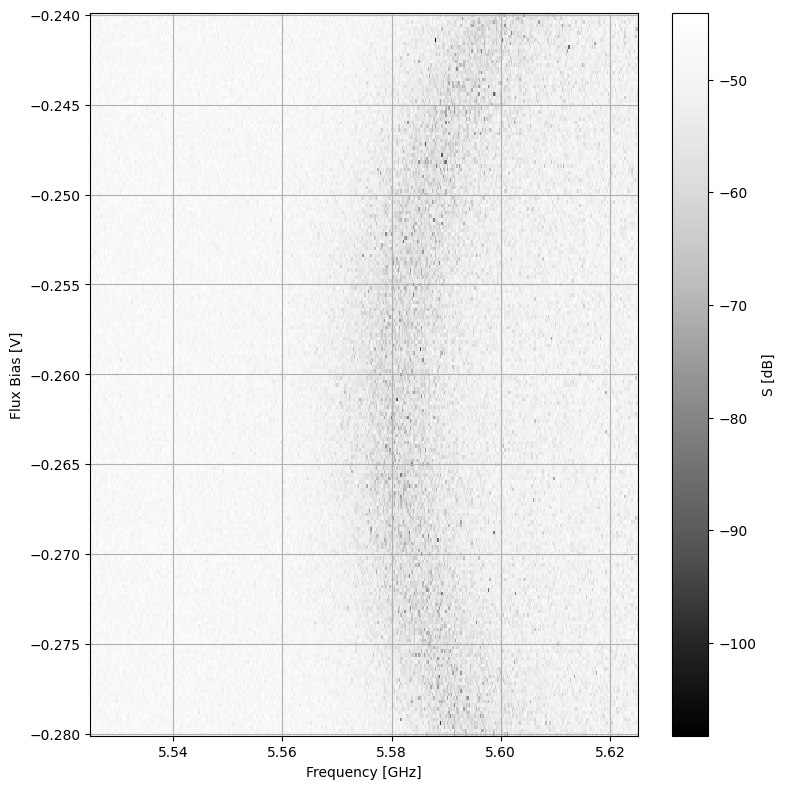

In [29]:
flux_sweep_start = -0.28
flux_sweep_stop = -0.24
flux_sweep_number_of_points = 201

qubit_flux_sweep = {}
qubit_flux_sweep['flux_bias'] = np.linspace(flux_sweep_start, flux_sweep_stop, flux_sweep_number_of_points)
qubit_flux_sweep['flux_bias'] = np.round(qubit_flux_sweep['flux_bias']*10000)/10000
qubit_flux_sweep['flux_bias'] = qubit_flux_sweep['flux_bias'].tolist()

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
qubit_flux_sweep['timestamp'] = int(now.timestamp())
qubit_flux_sweep['date'] = now.strftime("%d-%m-%Y")
qubit_flux_sweep['time'] = now.strftime("%H:%M:%S")
qubit_flux_sweep['timezone'] = now.tzname()
qubit_flux_sweep['temperature'] = '0.017'
qubit_flux_sweep['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + qubit_flux_sweep['date'] + " Plots\n\n")

qubit_flux_sweep['programmable_attenuator'] = get_attenuation_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)

vna_state = {}
vna_state['idn'] = vna.query('*IDN?')
vna_state['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_state['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_state['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_state['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_state['power']      = float(vna.query('SOURce1:POWer?'))

frequencies = np.linspace(vna_state['fstart'],vna_state['fstop'],vna_state['numpoints'])
fghz = frequencies/1e9
qubit_flux_sweep['fghz'] = fghz.tolist()
qubit_flux_sweep['vna'] = vna_state

qubit_flux_sweep['s_db'] = []
qubit_flux_sweep['s_deg'] = []

for flux_bias in qubit_flux_sweep['flux_bias']:
    yoko.write(f":SOUR:LEV {flux_bias:.4f}")
    print(f"flux_bias: {flux_bias:.4f} V   ", end="\r", flush=True)
    #print(flux_bias)
    vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
    vna.write("FORM REAL,32") 
    vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
    vna.write("INITiate:CONTinuous OFF")
    vna.write("INITiate:IMMediate")  
    opc_done = vna.query("*OPC?").strip()    
    if opc_done != "1":
        print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
        exit()
    raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
    vna.write("INITiate:CONTinuous ON")
    vna.go_to_local()
    real_parts = np.array(raw_floats[0::2])
    imag_parts = np.array(raw_floats[1::2])
    complex_trace = real_parts + 1j * imag_parts
    s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
    s_matrix[:, 0, 0] = complex_trace
    trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
    qubit_flux_sweep['s_db'].append(trace_network.s_db[:,0,0])
    qubit_flux_sweep['s_deg'].append(trace_network.s_deg[:,0,0])
    time.sleep(0.05)
qubit_flux_sweep['s_db'] = np.array(qubit_flux_sweep['s_db'])
qubit_flux_sweep['s_deg'] = np.array(qubit_flux_sweep['s_deg'])
    
now = datetime.now().astimezone()
qubit_flux_sweep['finish_time'] = int(now.timestamp())
qubit_flux_sweep['sweep_time'] = qubit_flux_sweep['finish_time'] - qubit_flux_sweep['start_time']
print(str(qubit_flux_sweep['sweep_time']) + " seconds sweep time")

qubit_flux_sweep['s_db'] = qubit_flux_sweep['s_db'].tolist()
qubit_flux_sweep['s_deg'] = qubit_flux_sweep['s_deg'].tolist()

sweep_file_name = f"{qubit_flux_sweep['timestamp']}-qubit-sweep.json"
file_path = target_dir / sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(qubit_flux_sweep, f, indent=4)



plt.figure(figsize=(8,8))
flux_bias = np.array(qubit_flux_sweep['flux_bias'])
fghz = np.array(qubit_flux_sweep['fghz'])
s = np.array(qubit_flux_sweep['s_db'])

mesh = plt.pcolormesh(
    fghz, 
    flux_bias, 
    s, 
    shading='auto', 
    cmap='Greys_r'
)

#plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Flux Bias [V]")

cbar = plt.colorbar(mesh)
cbar.set_label("S [dB]")

plt.tight_layout()
plt.grid()


plot_file_name = f"{qubit_flux_sweep['timestamp']}-qubit-sweep-plot.png"

with open(readme_path, "a") as file:
    file.write("![]("+ plot_file_name + ")\n")

with open(readme_path, "a") as file:
    file.write("\n### ![]("+ sweep_file_name + ")\n")

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()
#plt.close()

yoko.write(f":SOUR:LEV 0")
vna.go_to_local()

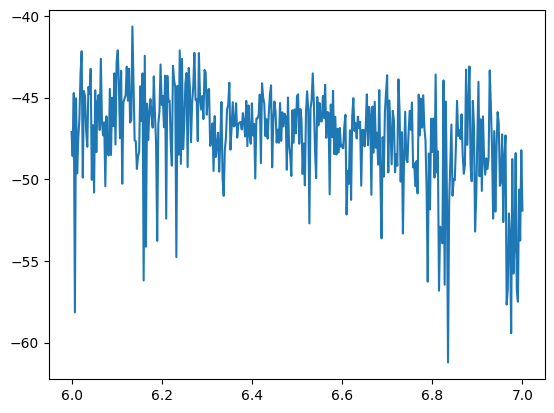

In [46]:
plt.plot(fghz,qubit_flux_sweep['s_db'][1])

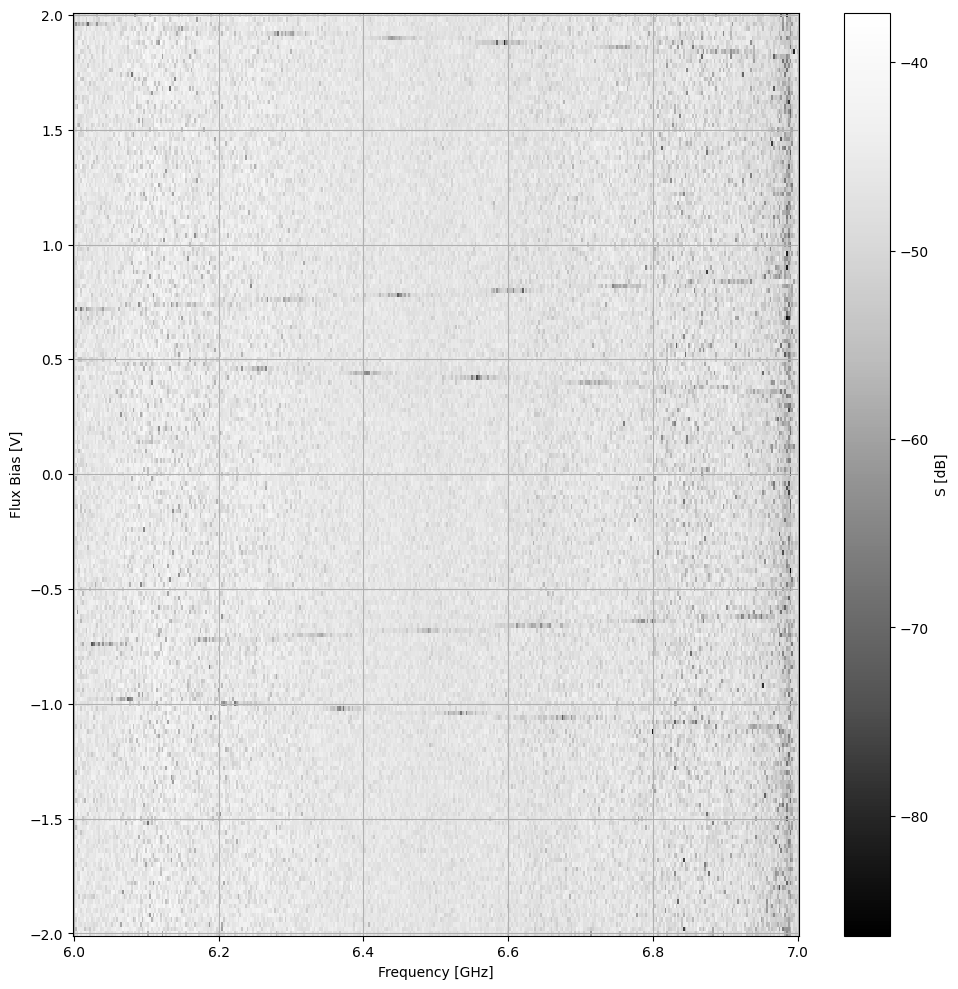

In [58]:
plt.figure(figsize=(10, 10))
flux_bias = np.array(qubit_flux_sweep['flux_bias'])
fghz = np.array(qubit_flux_sweep['fghz'])
s = np.array(qubit_flux_sweep['s_db'])

mesh = plt.pcolormesh(
    fghz, 
    flux_bias, 
    s, 
    shading='auto', 
    cmap='Greys_r'
)
#plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Flux Bias [V]")

cbar = plt.colorbar(mesh)
cbar.set_label("S [dB]")

plt.tight_layout()
plt.grid()


In [54]:
type(qubit_flux_sweep['flux_bias'])

list

In [67]:
qubit_flux_sweep['vna']['power']

-35.0

In [9]:
yoko.query('*IDN?').strip()

'YOKOGAWA,GS210,91U322681,2.02'

In [13]:
yoko.query(':SOURce:RANGe?').strip()

'10E+0'

In [12]:
yoko.write(':SOUR:RANG 10')

15

In [14]:
yoko.query(':OUTP?').strip()

'1'

In [16]:
qubit_flux_sweep.keys()

dict_keys(['flux_bias', 'timestamp', 'date', 'time', 'timezone', 'temperature', 'start_time', 'programmable_attenuator', 'fghz', 'vna', 's_db', 's_deg', 'finish_time', 'sweep_time'])

In [19]:
print(qubit_flux_sweep['programmable_attenuator'])
print(qubit_flux_sweep['vna']['power'])


25.0
-30.0


In [23]:
vna.query(':SENS1:FREQ:STOP?')

'5700000000'

In [28]:
vna.write(':SENS1:FREQ:START 5.525E9')
vna.write(':SENS1:FREQ:STOP 5.625E9')


In [26]:
vna.query(':SENS1:SWEep:POINts?')


'401'

In [25]:
vna.write(':SENS1:SWEep:POINts 401')